# Bibliotekos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from scipy import stats

from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

import Lasso

# Duomenys

In [2]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")
data['observationTime'] = pd.to_datetime(data['observationTime'])
data.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'BrO_Error', 'NO2', 'NO2_Error',
       'O3', 'O3_Error', 'pm10', 'pm2p5', 'sia', 'nmvoc', 'dust', 'nh3',
       'pans', 'tp', 't2m', 'airTemperature', 'seaLevelPressure',
       'relativeHumidity', 'missforest_precipitation', 'xgb_cloudCover',
       'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed',
       'windDirection_fixed'],
      dtype='object')

In [3]:
data = data.drop(columns=['BrO_Error', 'NO2_Error', 'O3_Error', 't2m'])
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

In [4]:
data.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'NO2', 'O3', 'pm10', 'pm2p5', 'sia',
       'nmvoc', 'dust', 'nh3', 'pans', 'tp', 'airTemperature',
       'seaLevelPressure', 'relativeHumidity', 'missforest_precipitation',
       'xgb_cloudCover', 'feelsLikeTemperature_fixed', 'windSpeed_fixed',
       'windGust_fixed', 'windDirection_fixed', 'month', 'day_of_year',
       'day_of_week'],
      dtype='object')

In [5]:
data.head(5)

,observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,NO2,O3,...,relativeHumidity,missforest_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,month,day_of_year,day_of_week
0,2018-07-01,-1.016247,0.000075,0.000062,0.000193,22057.926,1136.782022,4.376100e+13,3.627587e+15,332.670633,...,72.791667,9.1,89.375000,10.933333,3.762500,13.9,356.0,7,182,6
1,2018-07-02,-0.800622,0.000079,0.000066,0.000196,22067.760,1229.531736,3.946727e+13,3.795988e+15,339.679410,...,94.000000,11.9,91.500000,10.429167,2.516667,7.0,327.0,7,183,0
2,2018-07-03,-0.621235,0.000077,0.000062,0.000203,19219.670,1314.680602,4.465846e+13,4.526218e+15,361.533268,...,90.041667,10.0,89.375000,13.387500,2.537500,8.3,271.0,7,184,1
3,2018-07-04,-0.659180,0.000072,0.000065,0.000146,19219.450,1824.427700,4.888972e+13,4.149200e+15,343.308865,...,88.291667,13.9,88.333333,13.591667,2.358333,8.7,288.0,7,185,2
4,2018-07-05,-1.010234,0.000079,0.000067,0.000198,19218.373,1257.064200,4.093649e+13,3.959891e+15,311.500626,...,70.208333,0.0,66.000000,16.291667,1.283333,6.1,293.0,7,186,3


# Random Forest realizacija

## Požymių sukūrimas

### Vėlavimai

In [6]:
def lags_fun(column_name, lag_value, data):
    
    new_col_name = f"{column_name}_lag-{lag_value}"
    data.loc[:, new_col_name] = data[column_name].shift(lag_value)

In [7]:
lags_info = {
    # DALELES
    'absorbing_aerosol_index': [8],
    'NO2_column_number_density': [1, 2, 3],
    'stratospheric_NO2_column_number_density': [1, 3, 7],
    'NO2_slant_column_number_density': [1, 2],
    'tropopause_pressure': [1],
    'H2O_column_number_density': [1, 2],
    'NO2': [1, 4, 9],
    'dust': [1, 4],
    'sia': [11],
    'pm2p5': [1, 11],
    # 'pans': [10, 18],
    'pans': [10],
    'nmvoc': [1, 2],
    'nh3': [1, 11],
    'pm10': [1, 11],

    # METEO
    'airTemperature': [1, 3, 9, 10],
    'seaLevelPressure': [1, 2],
    'relativeHumidity': [1, 2],
    'xgb_cloudCover': [1, 2],
    'windSpeed_fixed': [1, 2, 3],
    'windGust_fixed': [1, 2],
    'windDirection_fixed': [4, 10]
}

for col, lags in lags_info.items():
    if isinstance(lags, list):
        for lag in lags:
            lags_fun(col, lag, data)
    else:
        lags_fun(col, lags, data)

In [8]:
data['target_precipitation'] = data['missforest_precipitation'].shift(-1)

### Rolling window

In [9]:
def rolling_window_fun(column_name, window_value, data):

    new_col_name = f"{column_name}_window-{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).mean().shift(1)

In [10]:
window_info = {
    # DALELES
    'absorbing_aerosol_index': [8],
    'NO2_column_number_density': [3, 2],
    'stratospheric_NO2_column_number_density': [3, 5, 7],
    'NO2_slant_column_number_density': [2],
    'H2O_column_number_density': [2],
    'NO2': [3, 5, 7],
    'dust': [4, 6, 8],
    'sia': [11],
    'pm2p5': [11],
    'pans': [10],
    'nmvoc': [3, 5],
    'nh3': [2, 4],
    'pm10': [5],

    # METEO
    'airTemperature': [4, 11],
    'seaLevelPressure': [3, 7],
    'seaLevelPressure': [7],
    'relativeHumidity': [3, 5],
    'xgb_cloudCover': [3, 5],
    'windSpeed_fixed': [4],
    'windGust_fixed': [3],
    'windDirection_fixed': [11]
}

for col, windows in window_info.items():
    if isinstance(windows, list):
        for window in windows:
            rolling_window_fun(col, window, data)
    else:
        rolling_window_fun(col, windows, data)

In [11]:
data_clean = data.dropna()

In [12]:
data_clean.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'NO2', 'O3',
       ...
       'airTemperature_window-4', 'airTemperature_window-11',
       'seaLevelPressure_window-7', 'relativeHumidity_window-3',
       'relativeHumidity_window-5', 'xgb_cloudCover_window-3',
       'xgb_cloudCover_window-5', 'windSpeed_fixed_window-4',
       'windGust_fixed_window-3', 'windDirection_fixed_window-11'],
      dtype='object', length=107)

## Požymių atrinkimas ir aibių sudarymas

### Aibių sudarymas I

In [13]:
train_end = '2024-02-01'
val_end = '2025-02-01'

train = data_clean[data_clean['observationTime'] < train_end]
val = data_clean[(data_clean['observationTime'] >= train_end) & (data_clean['observationTime'] <= val_end)]
test  = data_clean[data_clean['observationTime'] > val_end]

print(f"Train: {train.shape}, nuo {train['observationTime'].min()} iki {train['observationTime'].max()}")
print(f"Val: {val.shape}, nuo {val['observationTime'].min()} iki {val['observationTime'].max()}")
print(f"Test:  {test.shape},  nuo {test['observationTime'].min()} iki {test['observationTime'].max()}")

Train: (2030, 107), nuo 2018-07-12 00:00:00 iki 2024-01-31 00:00:00
Val: (367, 107), nuo 2024-02-01 00:00:00 iki 2025-02-01 00:00:00
Test:  (363, 107),  nuo 2025-02-02 00:00:00 iki 2026-01-30 00:00:00


### Požymiai atrinkti pagal LASSO

In [14]:
target = 'target_precipitation'
selected_features = Lasso.select_features_lasso(train.drop(columns=['observationTime']), target)

Pradinis požymių skaičius: 105
Išlikusių požymių skaičius: 29
Geriausias lambda (alpha): 0.0509
Pašalinti požymiai: ['stratospheric_NO2_column_number_density_lag-7', 'nmvoc_window-5', 'windSpeed_fixed_window-4', 'airTemperature_lag-1', 'NO2_window-3', 'dust_window-6', 'windSpeed_fixed', 'pm2p5_window-11', 'windGust_fixed_lag-2', 'xgb_cloudCover_lag-2', 'NO2_column_number_density_window-2', 'H2O_column_number_density_window-2', 'pm2p5_lag-11', 'airTemperature_window-4', 'NO2_window-5', 'NO2_column_number_density_lag-3', 'pans_window-10', 'stratospheric_NO2_column_number_density_lag-1', 'nmvoc_window-3', 'day_of_year', 'dust_lag-4', 'windSpeed_fixed_lag-2', 'windGust_fixed_lag-1', 'nmvoc_lag-1', 'day_of_week', 'NO2_column_number_density_lag-1', 'airTemperature_lag-3', 'NO2_window-7', 'sia_window-11', 'feelsLikeTemperature_fixed', 'dust', 'xgb_cloudCover_window-5', 'airTemperature_lag-10', 'windDirection_fixed_window-11', 'relativeHumidity', 'pm2p5_lag-1', 'relativeHumidity_window-5', 'H2

In [15]:
selected_features

['NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'pm10',
 'pm2p5',
 'nmvoc',
 'nh3',
 'tp',
 'seaLevelPressure',
 'xgb_cloudCover',
 'windDirection_fixed',
 'NO2_slant_column_number_density_lag-1',
 'tropopause_pressure_lag-1',
 'H2O_column_number_density_lag-1',
 'sia_lag-11',
 'pans_lag-10',
 'nmvoc_lag-2',
 'nh3_lag-11',
 'pm10_lag-1',
 'seaLevelPressure_lag-2',
 'relativeHumidity_lag-2',
 'xgb_cloudCover_lag-1',
 'windDirection_fixed_lag-4',
 'windDirection_fixed_lag-10',
 'NO2_slant_column_number_density_window-2',
 'dust_window-8',
 'nh3_window-2',
 'nh3_window-4']

In [16]:
Lasso_full_selected_importances = ['tp', 'pm10', 'H2O_column_number_density_lag-1', 'H2O_column_number_density', 'nh3',
                                   'NO2_column_number_density', 'tropopause_pressure', 'pm2p5', 'xgb_cloudCover',
                                   'pm10_lag-1', 'windDirection_fixed_lag-10', 'nh3_window-2', 'NO2_slant_column_number_density_lag-1',
                                   'NO2_slant_column_number_density_window-2', 'nh3_lag-11', 'pans_lag-10', 'relativeHumidity_lag-2']

Lasso_full_selected_importances2 = ['tp', 'H2O_column_number_density_lag-1', 'pm10', 'tropopause_pressure', 'H2O_column_number_density',
                                    'nh3', 'windDirection_fixed_lag-10', 'NO2_slant_column_number_density_window-2', 'pans_lag-10',
                                    'pm10_lag-1', 'xgb_cloudCover', 'nh3_lag-11', 'pm2p5', 'NO2_column_number_density',
                                    'nh3_window-2', 'relativeHumidity_lag-2', 'NO2_slant_column_number_density_lag-1']

Lasso_lag_selected_importances = ['tp', 'H2O_column_number_density_lag-1', 'pm10', 'H2O_column_number_density', 'nh3',
                                  'tropopause_pressure', 'windDirection_fixed_lag-10', 'pm10_lag-1', 'nh3_lag-1',
                                  'xgb_cloudCover', 'pm2p5', 'relativeHumidity_lag-1', 'windDirection_fixed_lag-4',
                                  'NO2_slant_column_number_density_lag-1', 'pans_lag-10', 'NO2_column_number_density',
                                  'sia_lag-11', 'nmvoc']

Lasso_lag_selected_importances2 = ['tp', 'H2O_column_number_density_lag-1', 'pm10', 'H2O_column_number_density',
                                   'tropopause_pressure', 'pm10_lag-1', 'xgb_cloudCover', 'NO2_column_number_density',
                                   'nh3', 'windDirection_fixed_lag-10', 'pans_lag-10', 'windDirection_fixed_lag-4',
                                   'relativeHumidity_lag-1', 'nh3_lag-1']

In [17]:
data_clean = data_clean[Lasso_full_selected_importances + ['observationTime', 'target_precipitation']].copy()

### Aibių sudarymas II

In [18]:
train_end = '2024-02-01'
val_end = '2025-02-01'

train = data_clean[data_clean['observationTime'] < train_end]
val = data_clean[(data_clean['observationTime'] >= train_end) & (data_clean['observationTime'] <= val_end)]
test  = data_clean[data_clean['observationTime'] > val_end]

print(f"Train: {train.shape}, nuo {train['observationTime'].min()} iki {train['observationTime'].max()}")
print(f"Val: {val.shape}, nuo {val['observationTime'].min()} iki {val['observationTime'].max()}")
print(f"Test:  {test.shape},  nuo {test['observationTime'].min()} iki {test['observationTime'].max()}")

Train: (2030, 19), nuo 2018-07-12 00:00:00 iki 2024-01-31 00:00:00
Val: (367, 19), nuo 2024-02-01 00:00:00 iki 2025-02-01 00:00:00
Test:  (363, 19),  nuo 2025-02-02 00:00:00 iki 2026-01-30 00:00:00


In [19]:
target = 'target_precipitation'
drop_cols = ['observationTime', target]

X_train = train.drop(columns=drop_cols)
y_train = train[target]

X_val = val.drop(columns=drop_cols)
y_val = val[target]

X_test = test.drop(columns=drop_cols)
y_test = test[target]

### Realizacija

In [20]:
X_train.columns

Index(['tp', 'pm10', 'H2O_column_number_density_lag-1',
       'H2O_column_number_density', 'nh3', 'NO2_column_number_density',
       'tropopause_pressure', 'pm2p5', 'xgb_cloudCover', 'pm10_lag-1',
       'windDirection_fixed_lag-10', 'nh3_window-2',
       'NO2_slant_column_number_density_lag-1',
       'NO2_slant_column_number_density_window-2', 'nh3_lag-11', 'pans_lag-10',
       'relativeHumidity_lag-2'],
      dtype='object')

In [21]:
rf_default = RandomForestRegressor(random_state=123)
rf_default.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [22]:
rf_default_pred_val = rf_default.predict(X_val)

### Metrikos

In [ ]:
def metrics_fun(y_val_true, rf_pred_val):
    print(f'R^2:  {r2_score(y_val_true, rf_pred_val)}')
    print(f'MAE:  {mean_absolute_error(y_val_true, rf_pred_val)}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_val_true, rf_pred_val))}')

    corr, p_value = stats.spearmanr(y_val_true, rf_pred_val)
    print(f"r_s:  {corr}")

Globalaus modelio paklaidos - validavimo aibė

In [24]:
metrics_fun(y_val, X_val['tp'])

R^2:  0.5026324749895323
MAE:  1.4685700168000633
RMSE: 3.40532484561435
r_s:  0.7378103776223065


RF modelio paklaidos

In [25]:
metrics_fun(y_val, rf_default_pred_val)

R^2:  0.5117894013202174
MAE:  1.419469882348794
RMSE: 3.3738318686469477
r_s:  0.7035535706324701


In [26]:
# Lasso požymiai:
# R^2:  0.39995691755304674
# MAE:  1.585614799922869
# RMSE: 3.7403397369682976
# r_s:  0.6809330318252551

# Lasso požymiai ir importances:   Pagal MAE ir RMSE pagerino globalu
# R^2:  0.5117894013202174
# MAE:  1.419469882348794
# RMSE: 3.3738318686469477
# r_s:  0.7035535706324701

# Lasso požymiai ir importances2:
# R^2:  0.5073629067433894
# MAE:  1.4294344282942464
# RMSE: 3.3890922396299685
# r_s:  0.7067183307198002

# Visų ir tik iš lagų:
# R^2:  0.4516585630830745
# MAE:  1.495323876319612
# RMSE: 3.5755706800914817
# r_s:  0.7063765424264007

# Visų ir tik iš lagų ir  importance:
# R^2:  0.5046910094967874
# MAE:  1.4699247772927173
# RMSE: 3.3982704575317055
# r_s:  0.7106188107124108

# Visų ir tik iš lagų ir importance2:
# R^2:  0.5186648119045512
# MAE:  1.4615026624020424
# RMSE: 3.3499910017369228
# r_s:  0.7001375787252804

In [27]:
len(rf_default_pred_val)

367

### Vizualizacija

In [28]:
plot_df = val.loc[y_val.index, ['observationTime', 'target_precipitation', 'tp']].copy()
plot_df['prediction'] = rf_default_pred_val
plot_df = plot_df.sort_values('observationTime')

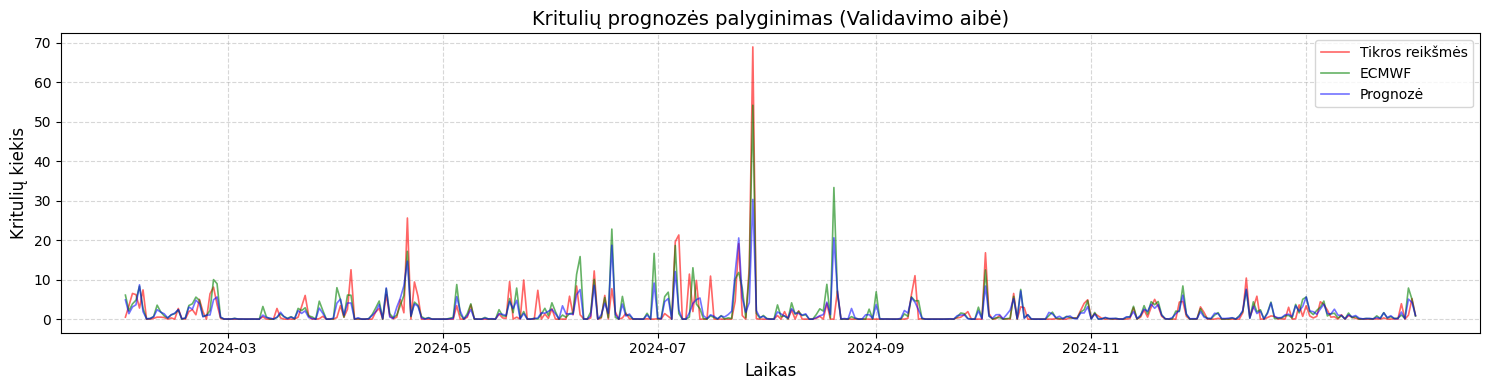

In [29]:
fig, ax1 = plt.subplots(figsize=(15, 4))
ax1.plot(plot_df['observationTime'], plot_df['target_precipitation'], label='Tikros reikšmės', color='red', linewidth=1.2, alpha=0.6)
ax1.plot(plot_df['observationTime'], plot_df['tp'], label='ECMWF', color='green', linewidth=1.2, alpha=0.6)
ax1.plot(plot_df['observationTime'], plot_df['prediction'], label='Prognozė', color='blue', linewidth=1.2, alpha=0.55)
ax1.legend(loc='upper right', fontsize=10, frameon=True)
ax1.set_title("Kritulių prognozės palyginimas (Validavimo aibė)", fontsize=14)
ax1.set_xlabel("Laikas", fontsize=12)
ax1.set_ylabel("Kritulių kiekis", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

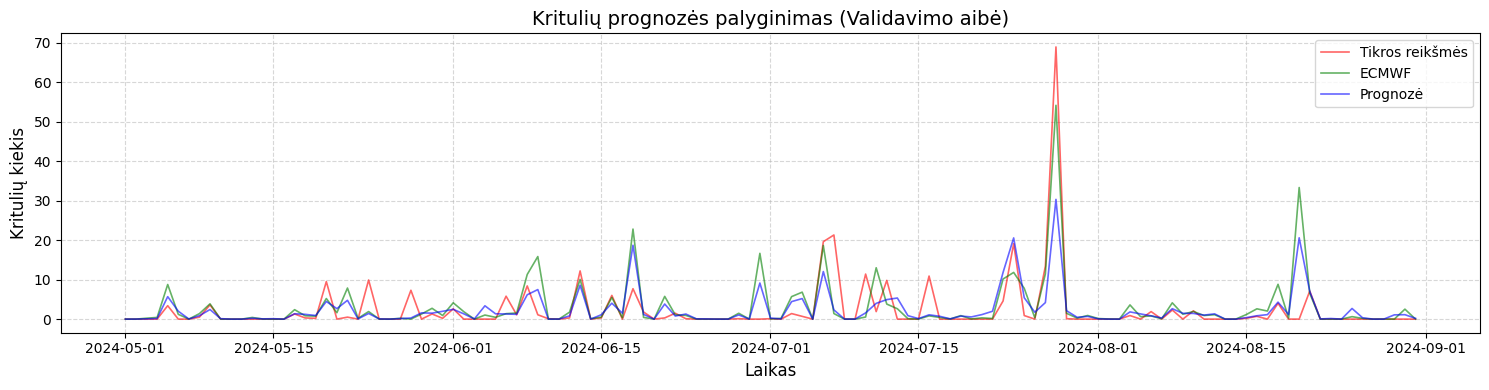

In [30]:
short_period = plot_df[(plot_df['observationTime'] >= '2024-05-01') & (plot_df['observationTime'] < '2024-09-01')]

fig, ax1 = plt.subplots(figsize=(15, 4))
ax1.plot(short_period['observationTime'], short_period['target_precipitation'], label='Tikros reikšmės', color='red', linewidth=1.2, alpha=0.6)
ax1.plot(short_period['observationTime'], short_period['tp'], label='ECMWF', color='green', linewidth=1.2, alpha=0.6)
ax1.plot(short_period['observationTime'], short_period['prediction'], label='Prognozė', color='blue', linewidth=1.2, alpha=0.6)
ax1.legend(loc='upper right', fontsize=10, frameon=True)
ax1.set_title("Kritulių prognozės palyginimas (Validavimo aibė)", fontsize=14)
ax1.set_xlabel("Laikas", fontsize=12)
ax1.set_ylabel("Kritulių kiekis", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

### Požymių reikšmingumas

In [31]:
rf_default_importances = rf_default.feature_importances_
rf_default_importances

array([0.53332687, 0.03987125, 0.06541044, 0.0473996 , 0.01949663,
       0.01419377, 0.0273652 , 0.0168031 , 0.01835239, 0.0416537 ,
       0.03352047, 0.03756122, 0.01909728, 0.01170151, 0.03671845,
       0.01759861, 0.0199295 ])

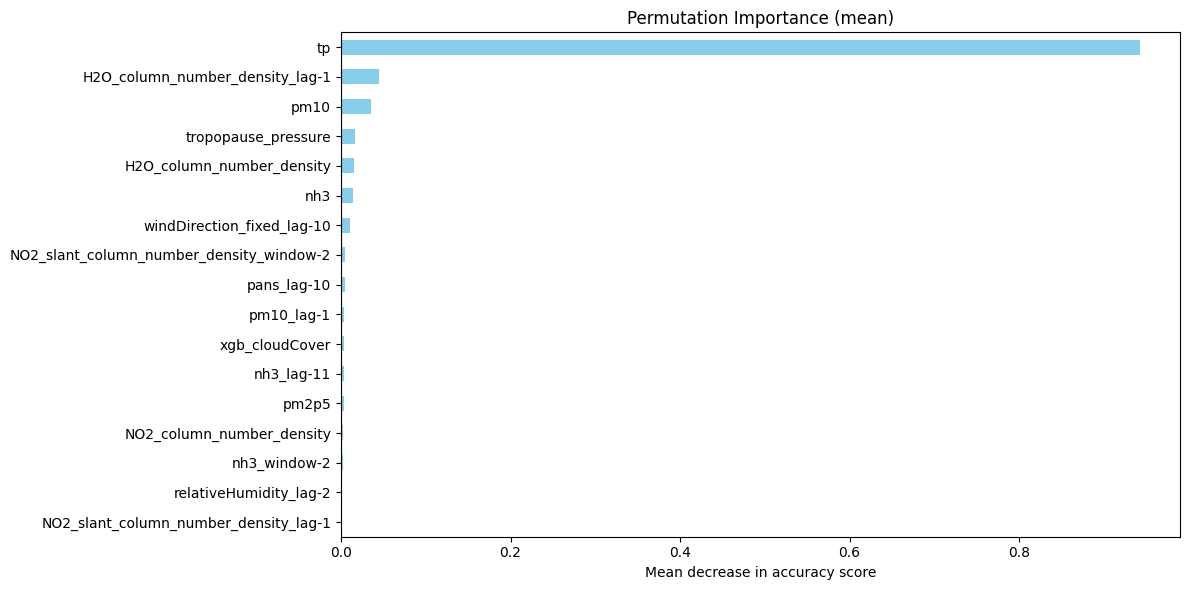

In [32]:
result = permutation_importance(rf_default, X_val, y_val, n_repeats=5, random_state=123)
sorted_importances_idx = result.importances_mean.argsort()
importances_df = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_val.columns[sorted_importances_idx]
)

forest_importances = pd.Series(result.importances_mean, index=X_val.columns)
forest_importances = forest_importances[forest_importances > 0]
forest_importances = forest_importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
forest_importances.plot.barh(ax=ax, color='skyblue')
ax.set_title("Permutation Importance (mean)")
ax.set_xlabel("Mean decrease in accuracy score")
ax.axvline(x=0, color="k", linestyle="--")

fig.tight_layout()
plt.show()

In [33]:
forest_importances

NO2_slant_column_number_density_lag-1       0.001139
relativeHumidity_lag-2                      0.001724
nh3_window-2                                0.002051
NO2_column_number_density                   0.002808
pm2p5                                       0.003027
nh3_lag-11                                  0.003112
xgb_cloudCover                              0.003440
pm10_lag-1                                  0.003896
pans_lag-10                                 0.004374
NO2_slant_column_number_density_window-2    0.004553
windDirection_fixed_lag-10                  0.010119
nh3                                         0.014586
H2O_column_number_density                   0.015509
tropopause_pressure                         0.016642
pm10                                        0.035953
H2O_column_number_density_lag-1             0.045015
tp                                          0.942606
dtype: float64

## Optimalių hiperparametrų atrinkimas

### Hiperparametrų kitimas

In [34]:
from sklearn.model_selection import validation_curve

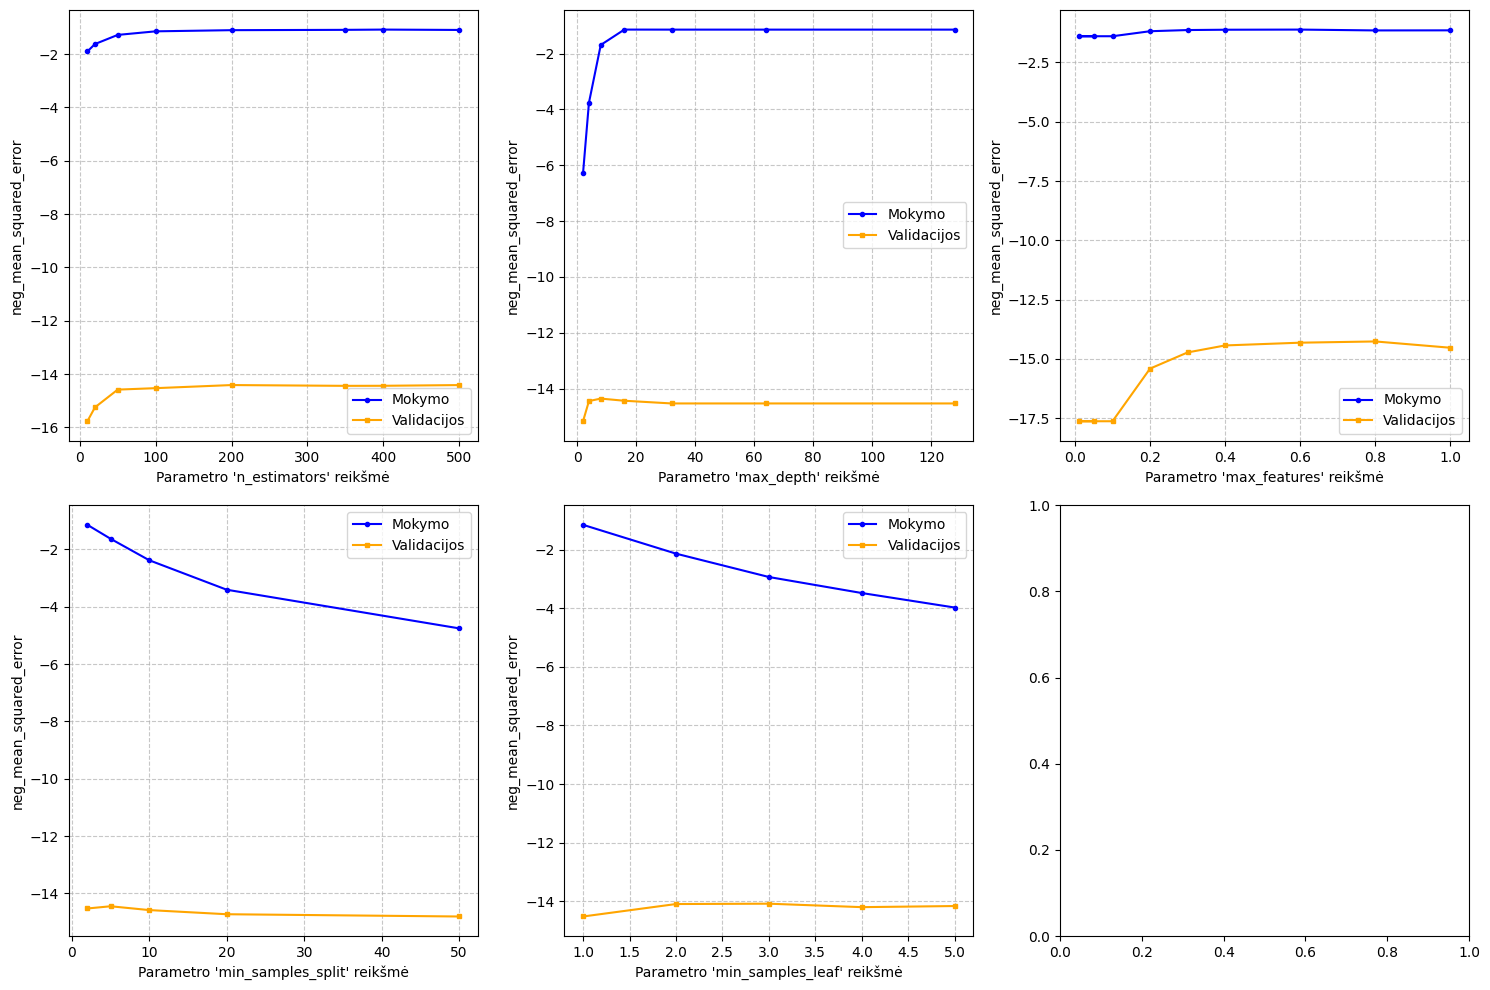

In [35]:
params = [
    {"name": "n_estimators", "range": [10, 20, 50, 100, 200, 350, 400, 500]},
    {"name": "max_depth", "range": [2, 4, 8, 16, 32, 64, 128]},
    {"name": "max_features", "range": [0.05, 0.01,  0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]},
    {"name": "min_samples_split", "range": [2, 5, 10, 20, 50]},
    {"name": "min_samples_leaf", "range": [1, 2, 3, 4, 5]}
]


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
tscv = TimeSeriesSplit(n_splits=5)

for i, p in enumerate(params):

    rf = RandomForestRegressor(random_state=123)
    
    train_scores, test_scores = validation_curve(
        rf, X_train, y_train, 
        param_name=p["name"], param_range=p["range"],
        cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    axes[i].plot(p["range"], train_mean, label="Mokymo", marker='o', color='blue', markersize=3)
    axes[i].plot(p["range"], test_mean, label="Validacijos", marker='s', color='orange', markersize=3)

    axes[i].set_xlabel(f"Parametro '{p['name']}' reikšmė")
    axes[i].set_ylabel("neg_mean_squared_error")
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [44]:
param_grid = {
    'n_estimators': [100, 120, 150, 180, 200],
    'max_depth': [None, 4, 8, 12, 16], 
    'max_features': [0.6, 0.7, 0.8, 0.9, 0.95, 1.0],
    'min_samples_split': [2, 3, 4, 5, 6, 7],
    'min_samples_leaf': [1, 2, 3, 4]
}

rf = RandomForestRegressor(random_state=123)

tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=tscv,
                           scoring='neg_root_mean_squared_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print(f"Geriausi parametrai: {grid_search.best_params_}")

Fitting 5 folds for each of 3600 candidates, totalling 18000 fits
Geriausi parametrai: {'max_depth': 8, 'max_features': 0.8, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}


In [45]:
best_model.fit(X_train, y_train)
best_model_pred_val = best_model.predict(X_val)

metrics_fun(y_val, best_model_pred_val)

R^2:  0.49619796904887437
MAE:  1.442997868842127
RMSE: 3.427281616382314
r_s:  0.7092831389558653


In [38]:
metrics_fun(y_val, rf_default_pred_val)

R^2:  0.5117894013202174
MAE:  1.419469882348794
RMSE: 3.3738318686469477
r_s:  0.7035535706324701


In [ ]:
# Geriausi parametrai: {'max_depth': 16, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 80}
# R^2:  0.5087670139459619
# MAE:  1.4403650461181072
# RMSE: 3.384259022147952
# r_s:  0.7066304422485203

# Geriausi parametrai: {'max_depth': 8, 'max_features': 0.9, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
# R^2:  0.5087670139459619
# MAE:  1.4403650461181072
# RMSE: 3.384259022147952
# r_s:  0.7066304422485203

# Geriausi parametrai: {'max_depth': 8, 'max_features': 0.8, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}
# R^2:  0.49619796904887437
# MAE:  1.442997868842127
# RMSE: 3.427281616382314
# r_s:  0.7092831389558653